<a href="https://colab.research.google.com/github/ashwinibarapatre28/Machine_Learning/blob/main/Practical10_ML_Extra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name : Ashwini K. Barapatre

USN : CS23118

Aim : To perform Hierarchical Clustering using agglomerative methods and interpret dendrograms for cluster formation.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/ML Dataset/Spotify_Songs_Dataset - Spotify_Songs_Dataset.csv"

df = pd.read_csv(file_path)

print(df.head())
print(df.info())

   Unnamed: 0                track_id                 artists  \
0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3           3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4           4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms explicit  danceability  \
0                      Comedy        73.0     230666.0    False         0.676   
1            Ghost - Acoustic        55.0     149610.0    False         0.420   
2              To Begin Again

In [ ]:
# Select required features
X = df[['tempo', 'energy', 'danceability']]

# Handle missing values (if any)
X = X.dropna()

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

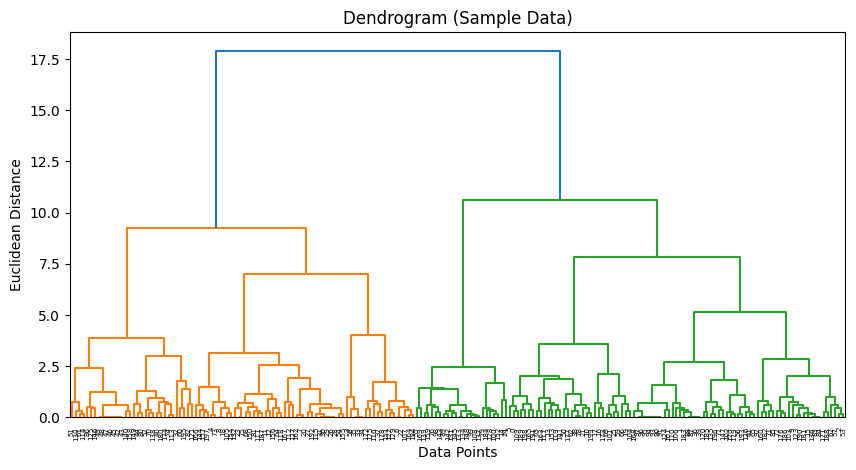

In [ ]:
import scipy.cluster.hierarchy as sch
import matplotlib.pyplot as plt

# Take small sample (important)
sample_data = X_scaled[:200]   # you can try 100–300

plt.figure(figsize=(10,5))

sch.dendrogram(
    sch.linkage(sample_data, method='ward')
)

plt.title('Dendrogram (Sample Data)')
plt.xlabel('Data Points')
plt.ylabel('Euclidean Distance')
plt.show()

In [ ]:
# Take only 500 samples (you can reduce to 300 if still slow)
X_sample = X.sample(n=500, random_state=42)

# Scale again (IMPORTANT)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled_sample = scaler.fit_transform(X_sample)

# Apply clustering
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
clusters = hc.fit_predict(X_scaled_sample)

# Add cluster labels
X_sample['Cluster'] = clusters

print(X_sample.head())

        tempo  energy  danceability  Cluster
3322  199.943   0.732         0.433        2
296   106.911   0.652         0.724        1
346   113.091   0.604         0.564        1
3007  110.018   0.863         0.496        1
544   100.672   0.516         0.448        1


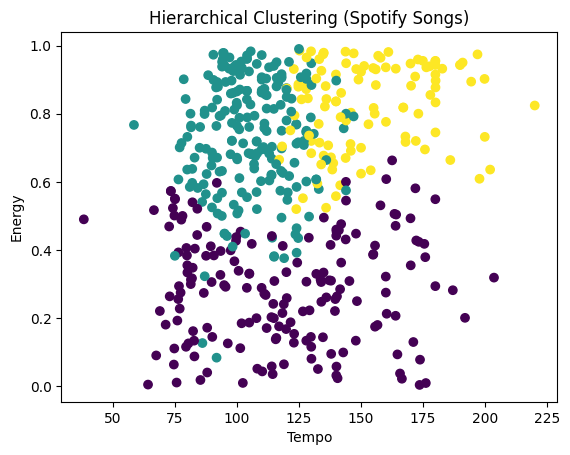

In [ ]:
plt.scatter(X_sample['tempo'], X_sample['energy'], c=clusters)

plt.xlabel('Tempo')
plt.ylabel('Energy')
plt.title('Hierarchical Clustering (Spotify Songs)')
plt.show()